# Regional Analysis

## 1. Clean Dataset

In [1]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Load
# -----------------------------
df = pd.read_parquet("../data/interim/vehicles_trimmed.parquet")

# -----------------------------
# 2. Type Cleaning
# -----------------------------
numeric_cols = ["year", "odometer", "price"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

df["posting_date"] = (
    pd.to_datetime(df["posting_date"], errors="coerce", utc=True)
      .dt.tz_localize(None)
)

# Ensure regional fields are strings
df["state"] = df["state"].astype("string")
df["region"] = df["region"].astype("string")
df["manufacturer"] = df["manufacturer"].astype("string")

# -----------------------------
# 3. Feature Engineering
# -----------------------------
df["vehicle_age"] = df["posting_date"].dt.year - df["year"]
df["cost_per_mile"] = df["price"] / df["odometer"]

df["log_price"] = np.log(df["price"])

df["model"] = (
    df["model"]
    .astype("string")
    .str.lower()
    .str.replace(r"[^a-z0-9 ]", "", regex=True)
    .str.strip()
)

# -----------------------------
# 4. Minimal Cleanup (BI-friendly)
# -----------------------------
# Only drop rows that break basic metrics
df = df.dropna(subset=["price", "odometer", "year", "state"])

# -----------------------------
# 5. Regional Analysis Dataset
# -----------------------------
regional_df = df[[
    "state", "region", "price", 
    "odometer", "vehicle_age",
    "cost_per_mile", "posting_date",
    "manufacturer", "model"
]].copy()


## 2. Check Data Types

In [2]:
# check dataframe types
df.dtypes

price                     int64
year                    float64
manufacturer     string[python]
model            string[python]
odometer                float64
state            string[python]
posting_date     datetime64[ns]
region           string[python]
vehicle_age             float64
cost_per_mile           float64
log_price               float64
dtype: object

## 3. State-Level Summary Table

In [2]:
state_summary = regional_df.groupby("state").agg(
    median_price=("price", "median"),
    avg_price=("price", "mean"),
    listing_count=("price", "count"),
    median_odometer=("odometer", "median"),
    median_vehicle_age=("vehicle_age", "median"),
    median_cpm=("cost_per_mile", "median")
).reset_index()
state_summary

,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
0,ak,22999.0,24977.934959,984,72460.0,6.0,0.324474
1,al,21990.0,22283.339623,1590,88097.5,7.0,0.246810
2,ar,20000.0,23002.866667,885,87715.0,6.0,0.241738
3,az,17998.0,22013.928882,2531,84437.0,8.0,0.223452
4,ca,15995.0,19648.730333,14885,91819.0,8.0,0.173700
5,co,17990.0,20703.135427,3153,99000.0,8.0,0.180804
6,ct,11985.0,16222.058013,1379,100000.0,9.0,0.112757
7,dc,13450.0,16036.534483,928,97136.5,9.0,0.141845
8,de,12000.0,18435.513514,259,114000.0,10.0,0.117949
9,fl,16995.0,20455.048928,9279,87595.0,8.0,0.191181


In [7]:
state_summary = regional_df.groupby("state").agg(
    median_price=("price", "median"),
    avg_price=("price", "mean"),
    listing_count=("price", "count"),
    median_odometer=("odometer", "median"),
    median_vehicle_age=("vehicle_age", "median"),
    median_cpm=("cost_per_mile", "median")
).reset_index()
state_summary.shape
state_summary.head()

,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
0,ak,22999.0,24977.934959,984,72460.0,6.0,0.324474
1,al,21990.0,22283.339623,1590,88097.5,7.0,0.246810
2,ar,20000.0,23002.866667,885,87715.0,6.0,0.241738
3,az,17998.0,22013.928882,2531,84437.0,8.0,0.223452
4,ca,15995.0,19648.730333,14885,91819.0,8.0,0.173700


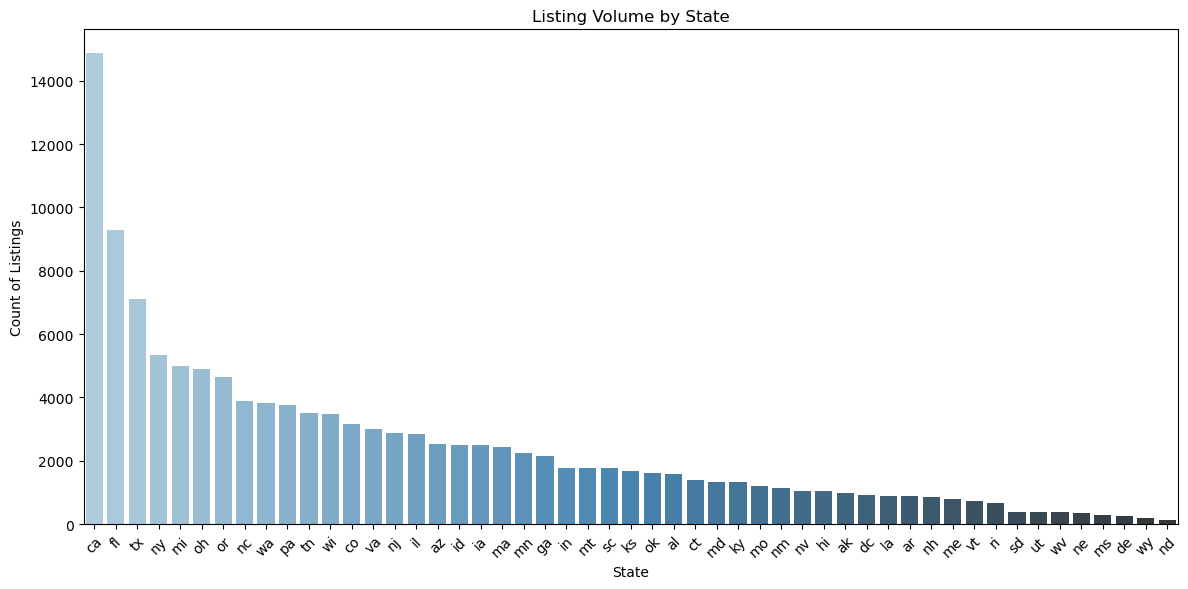

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by listing_count descending
plot_df = state_summary.sort_values("listing_count", ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="state",
    y="listing_count",
    hue="state",
    palette="Blues_d",
    legend=False
)

plt.title("Listing Volume by State")
plt.xlabel("State")
plt.ylabel("Count of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Regional Price Trends Over Time

In [5]:
regional_df["posting_date"] = pd.to_datetime(regional_df["posting_date"])

state_trends = (
    regional_df
    .groupby([regional_df["posting_date"].dt.to_period("M"), "state"])
    .agg(avg_price=("price", "mean"))
    .reset_index()
)

state_trends["posting_date"] = state_trends["posting_date"].dt.to_timestamp()
state_trends

,posting_date,state,avg_price
0,2021-04-01,ak,25567.135593
1,2021-04-01,al,22568.564480
2,2021-04-01,ar,23284.394737
3,2021-04-01,az,23370.561709
4,2021-04-01,ca,20394.489195
...,...,...,...
97,2021-05-01,vt,15219.546875
98,2021-05-01,wa,23937.676080
99,2021-05-01,wi,15877.792308
100,2021-05-01,wv,21657.181818


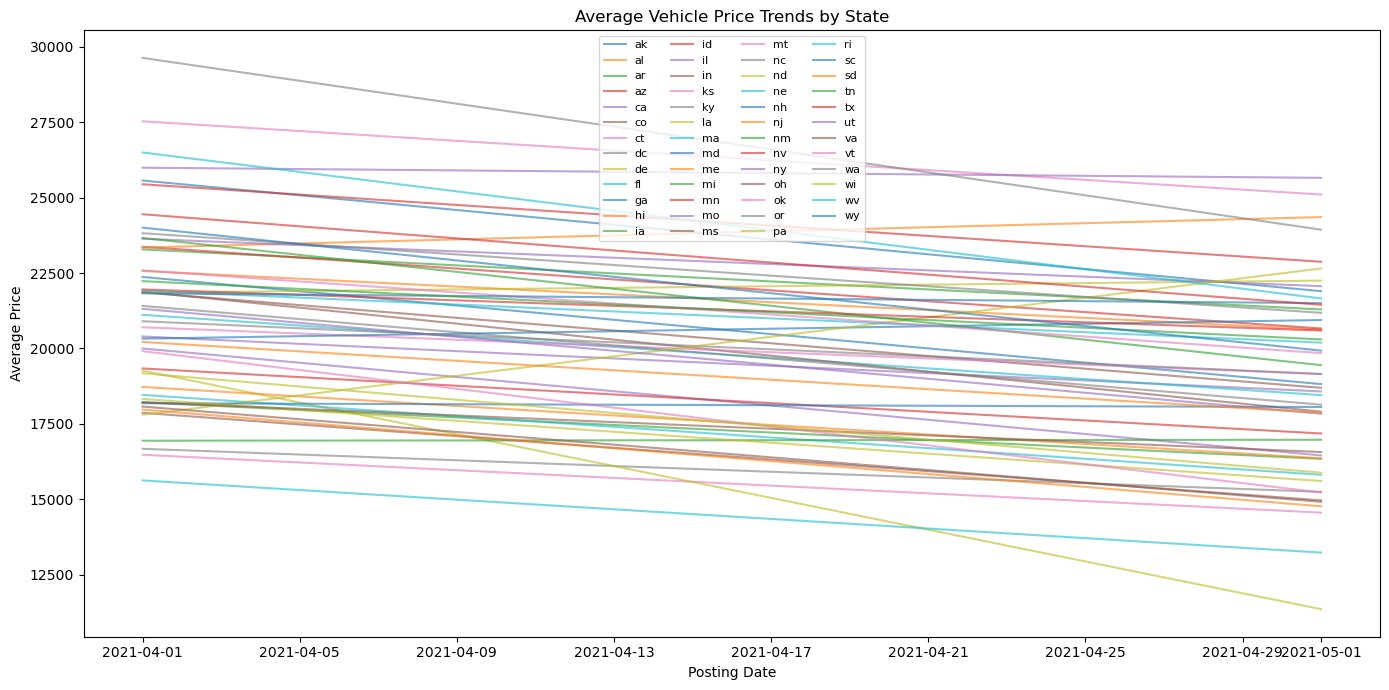

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for state in state_trends["state"].unique():
    subset = state_trends[state_trends["state"] == state]
    plt.plot(subset["posting_date"], subset["avg_price"], label=state, alpha=0.6)

plt.title("Average Vehicle Price Trends by State")
plt.xlabel("Posting Date")
plt.ylabel("Average Price")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

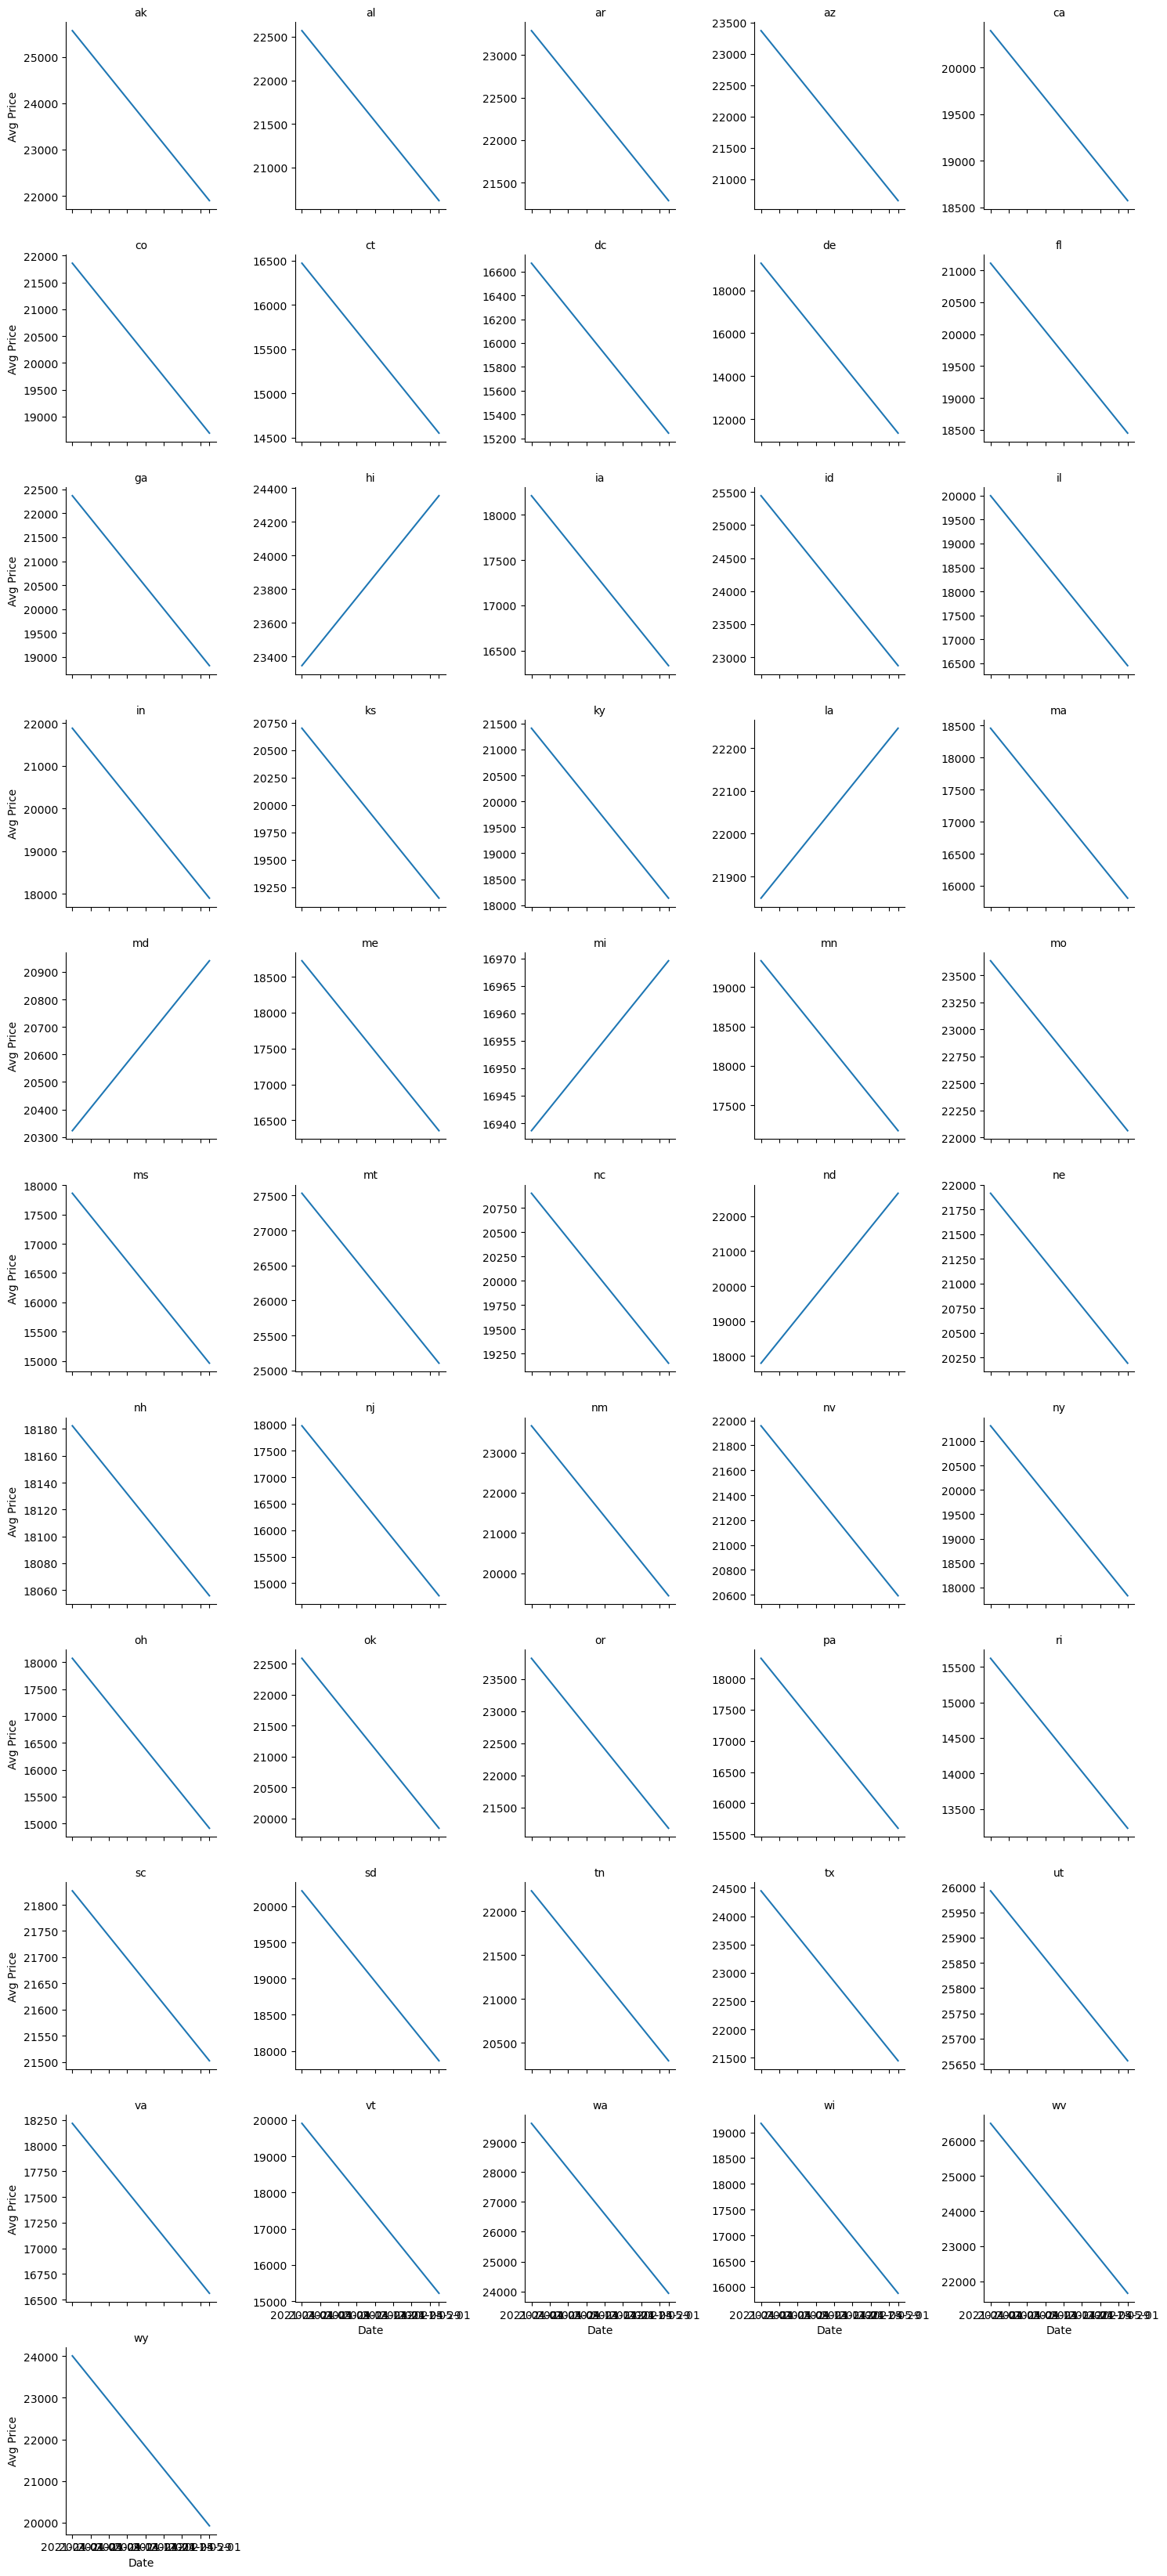

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.FacetGrid(state_trends, col="state", col_wrap=5, height=3, sharey=False)
g.map_dataframe(sns.lineplot, x="posting_date", y="avg_price")
g.set_titles("{col_name}")
g.set_axis_labels("Date", "Avg Price")
plt.tight_layout()
plt.show()

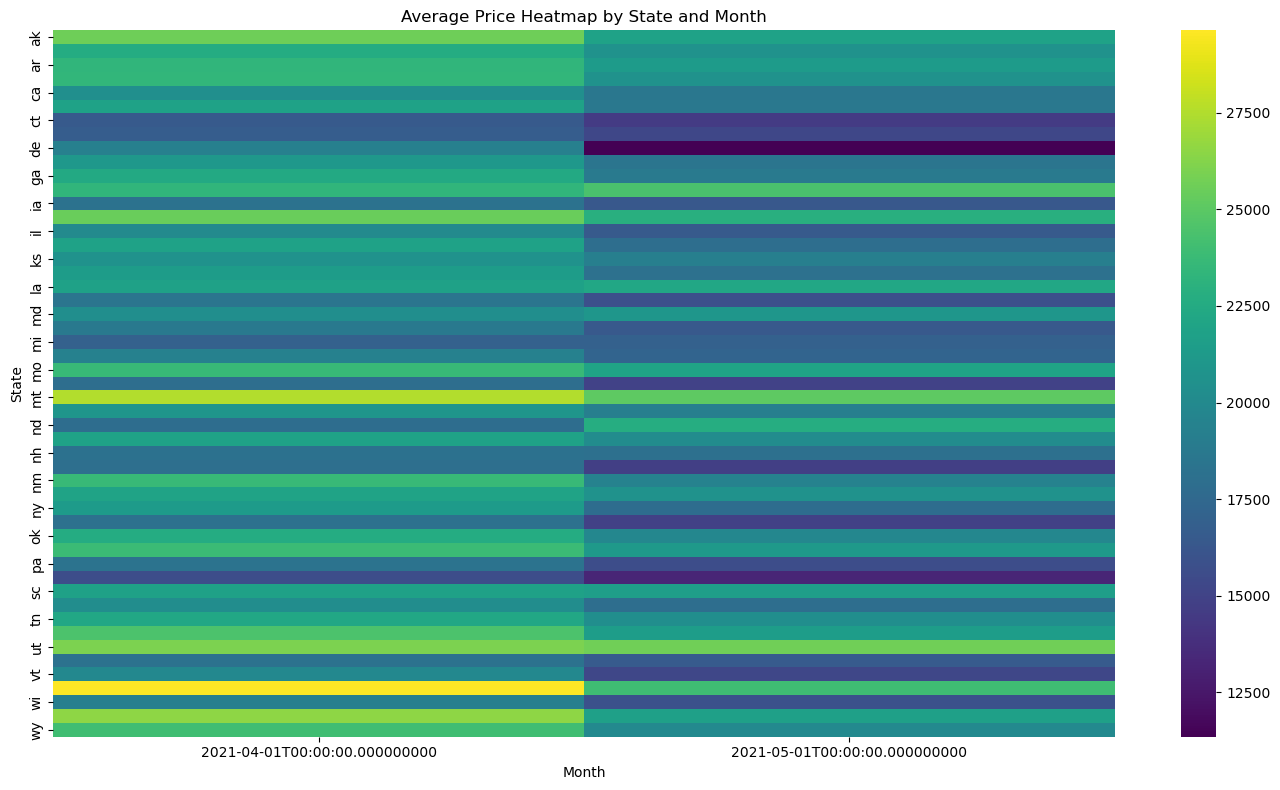

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot = state_trends.pivot_table(
    index="state",
    columns="posting_date",
    values="avg_price"
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap="viridis")
plt.title("Average Price Heatmap by State and Month")
plt.xlabel("Month")
plt.ylabel("State")
plt.tight_layout()
plt.show()

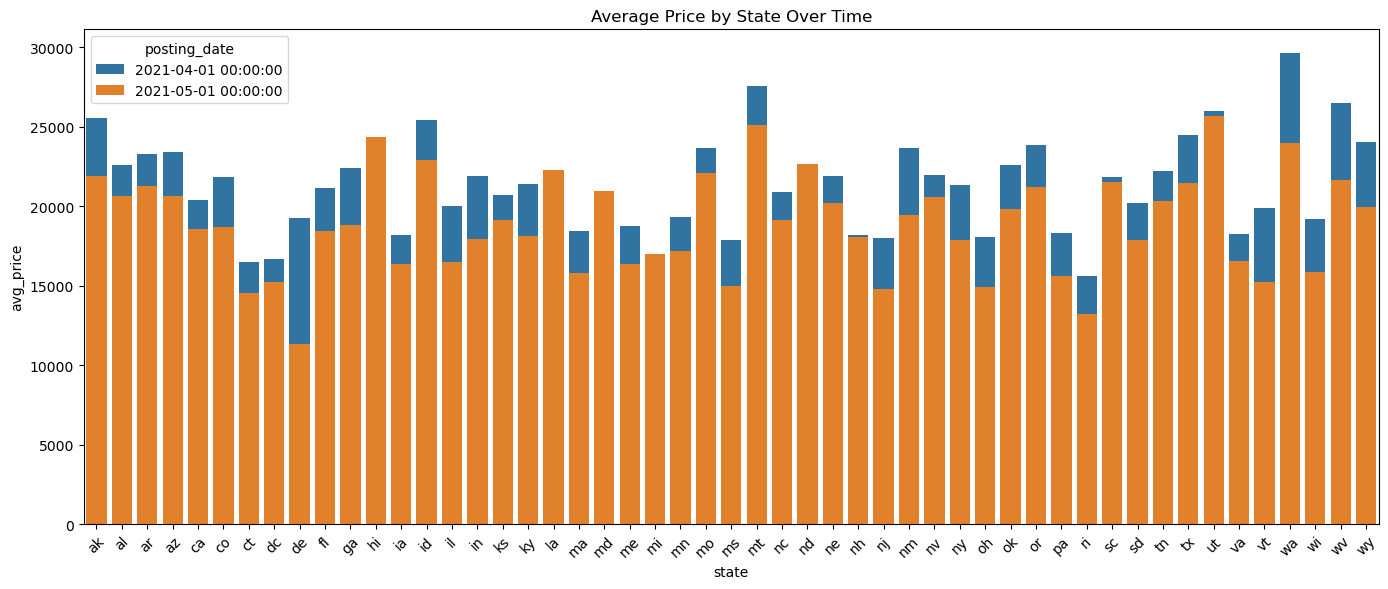

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.barplot(
    data=state_trends,
    x="state",
    y="avg_price",
    hue="posting_date",
    dodge=False
)
plt.xticks(rotation=45)
plt.title("Average Price by State Over Time")
plt.tight_layout()
plt.show()

## 5. Manufacturer Mix by State

In [10]:
mfg_mix = (
    regional_df
    .groupby(["state", "manufacturer"])
    .size()
    .reset_index(name="listing_count")
)
mfg_mix

,state,manufacturer,listing_count
0,ak,bmw,118
1,ak,cadillac,30
2,ak,ford,533
3,ak,infiniti,11
4,ak,mercedes-benz,53
...,...,...,...
349,wy,cadillac,9
350,wy,ford,109
351,wy,infiniti,7
352,wy,mercedes-benz,15


## 6. Cost‑Per‑Mile Value Ranking

In [11]:
cpm_by_state = (
    regional_df.groupby("state")["cost_per_mile"]
    .median()
    .reset_index()
    .sort_values("cost_per_mile")
)
cpm_by_state

,state,cost_per_mile
39,ri,0.093711
22,mi,0.103810
6,ct,0.112757
8,de,0.117949
25,ms,0.130978
21,me,0.135265
38,pa,0.139847
19,ma,0.140876
7,dc,0.141845
31,nj,0.147217


## 7. Normalize price for regional comparison

In [12]:
state_medians = regional_df.groupby("state")["price"].median()

regional_df["price_index"] = regional_df.apply(
    lambda r: r["price"] / state_medians[r["state"]],
    axis=1
)
regional_df

,state,region,price,odometer,vehicle_age,cost_per_mile,posting_date,manufacturer,model,price_index
0,al,auburn,30990,41124.0,4.0,0.753575,2021-05-04 15:41:31,toyota,tundra double cab sr,1.409277
1,al,auburn,15000,128000.0,8.0,0.117188,2021-05-03 19:02:03,ford,f150 xlt,0.682128
2,al,auburn,35000,43000.0,2.0,0.813953,2021-05-03 17:12:59,toyota,tacoma,1.591633
3,al,auburn,27990,17805.0,7.0,1.572030,2021-05-02 13:44:35,toyota,tacoma access cab pickup,1.272851
4,al,auburn,33590,55251.0,7.0,0.607953,2021-05-01 14:21:37,toyota,tundra crewmax sr5 pickup,1.527513
...,...,...,...,...,...,...,...,...,...,...
123446,wy,wyoming,32990,55612.0,5.0,0.593217,2021-04-05 08:41:26,infiniti,qx80 sport utility 4d,1.460381
123447,wy,wyoming,32590,19059.0,1.0,1.709953,2021-04-04 09:21:35,mercedes-benz,cclass c 300,1.442674
123448,wy,wyoming,30990,15080.0,3.0,2.055040,2021-04-04 09:21:35,mercedes-benz,glc 300 sport,1.371846
123449,wy,wyoming,34990,4174.0,1.0,8.382846,2021-04-04 09:21:17,cadillac,xt4 sport suv 4d,1.548915


## 8. Which states have the highest and lowest vehicle prices?

In [13]:
# Highest and lowest median price by state
price_rank = state_summary.sort_values("median_price", ascending=False)

print("Top 5 Highest Price States:")
display(price_rank.head())

print("Top 5 Lowest Price States:")
display(price_rank.tail())


Top 5 Highest Price States:


,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
49,wv,27196.5,25912.343407,364,70480.0,6.0,0.362609
26,mt,25998.0,27172.536544,1765,76868.0,6.0,0.359520
47,wa,23999.0,27837.308881,3817,72722.0,6.0,0.310644
44,ut,23000.0,25942.409214,369,85128.0,8.0,0.229565
0,ak,22999.0,24977.934959,984,72460.0,6.0,0.324474


Top 5 Lowest Price States:


,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
7,dc,13450.0,16036.534483,928,97136.5,9.0,0.141845
22,mi,12900.0,16945.204295,4983,115812.0,9.0,0.103810
8,de,12000.0,18435.513514,259,114000.0,10.0,0.117949
6,ct,11985.0,16222.058013,1379,100000.0,9.0,0.112757
39,ri,10997.0,15184.442136,674,113717.0,10.0,0.093711


## 9. Which states offer the best value (lowest cost‑per‑mile)?

In [14]:
cpm_rank = state_summary.sort_values("median_cpm")

print("Top 5 Best Value States (Lowest CPM):")
display(cpm_rank.head())

print("Top 5 Worst Value States (Highest CPM):")
display(cpm_rank.tail())

Top 5 Best Value States (Lowest CPM):


,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
39,ri,10997.0,15184.442136,674,113717.0,10.0,0.093711
22,mi,12900.0,16945.204295,4983,115812.0,9.0,0.103810
6,ct,11985.0,16222.058013,1379,100000.0,9.0,0.112757
8,de,12000.0,18435.513514,259,114000.0,10.0,0.117949
25,ms,14900.0,17466.645614,285,130000.0,8.0,0.130978


Top 5 Worst Value States (Highest CPM):


,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
47,wa,23999.0,27837.308881,3817,72722.0,6.0,0.310644
0,ak,22999.0,24977.934959,984,72460.0,6.0,0.324474
26,mt,25998.0,27172.536544,1765,76868.0,6.0,0.359520
49,wv,27196.5,25912.343407,364,70480.0,6.0,0.362609
11,hi,21881.0,23937.650824,1031,48771.0,6.0,0.466935


## 10. Are certain states selling older or newer vehicles?

In [15]:
age_rank = state_summary.sort_values("median_vehicle_age")

print("States with Newest Vehicles:")
display(age_rank.head())

print("States with Oldest Vehicles:")
display(age_rank.tail())

States with Newest Vehicles:


,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
0,ak,22999.0,24977.934959,984,72460.0,6.0,0.324474
47,wa,23999.0,27837.308881,3817,72722.0,6.0,0.310644
2,ar,20000.0,23002.866667,885,87715.0,6.0,0.241738
43,tx,20995.0,23458.346067,7120,85548.0,6.0,0.261168
26,mt,25998.0,27172.536544,1765,76868.0,6.0,0.359520


States with Oldest Vehicles:


,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
37,or,18990.0,22934.732846,4649,98606.0,9.0,0.176108
6,ct,11985.0,16222.058013,1379,100000.0,9.0,0.112757
22,mi,12900.0,16945.204295,4983,115812.0,9.0,0.103810
39,ri,10997.0,15184.442136,674,113717.0,10.0,0.093711
8,de,12000.0,18435.513514,259,114000.0,10.0,0.117949


## 11. How does listing volume vary by state?

In [16]:
volume_rank = state_summary.sort_values("listing_count", ascending=False)

print("States with Most Listings:")
display(volume_rank.head())

print("States with Fewest Listings:")
display(volume_rank.tail())

States with Most Listings:


,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
4,ca,15995.0,19648.730333,14885,91819.0,8.0,0.173700
9,fl,16995.0,20455.048928,9279,87595.0,8.0,0.191181
43,tx,20995.0,23458.346067,7120,85548.0,6.0,0.261168
34,ny,17545.0,20378.463858,5340,79000.0,8.0,0.232612
22,mi,12900.0,16945.204295,4983,115812.0,9.0,0.103810


States with Fewest Listings:


,state,median_price,avg_price,listing_count,median_odometer,median_vehicle_age,median_cpm
29,ne,16900.0,21622.807580,343,84961.0,7.0,0.197336
25,ms,14900.0,17466.645614,285,130000.0,8.0,0.130978
8,de,12000.0,18435.513514,259,114000.0,10.0,0.117949
50,wy,22590.0,23580.067708,192,80272.0,7.0,0.246655
28,nd,16990.0,18585.162393,117,115811.0,8.0,0.160053


## 12. How do prices change over time in each state?

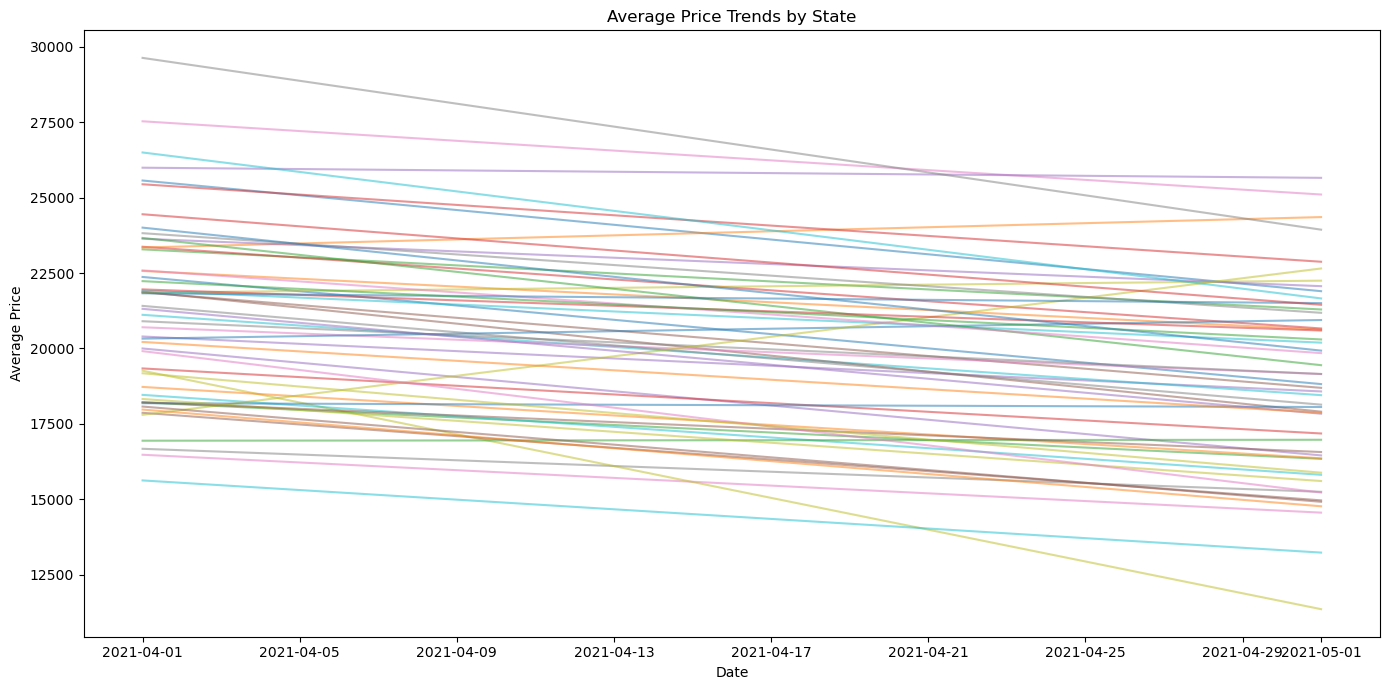

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for state in state_trends["state"].unique():
    subset = state_trends[state_trends["state"] == state]
    plt.plot(subset["posting_date"], subset["avg_price"], alpha=0.5)

plt.title("Average Price Trends by State")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

## 13. Are there seasonal patterns in pricing?

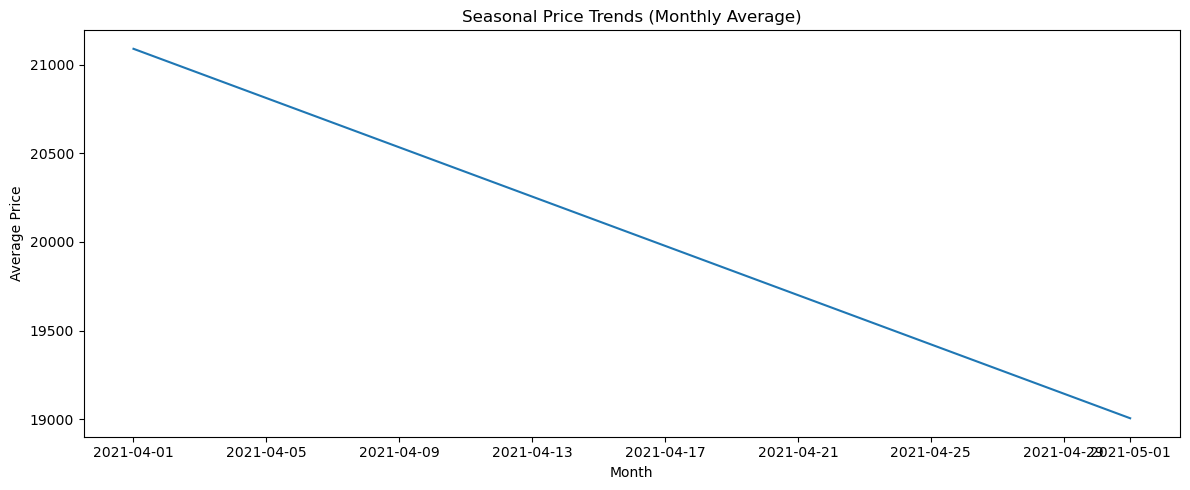

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly = (
    regional_df
    .groupby(regional_df["posting_date"].dt.to_period("M"))
    .agg(avg_price=("price", "mean"))
    .reset_index()
)

monthly["posting_date"] = monthly["posting_date"].dt.to_timestamp()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="posting_date", y="avg_price")
plt.title("Seasonal Price Trends (Monthly Average)")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

## 14. Do some states deviate from national pricing trends?

In [19]:
# National trend
national = monthly.rename(columns={"avg_price": "national_avg"})

merged = state_trends.merge(national, on="posting_date", how="left")
merged["difference"] = merged["avg_price"] - merged["national_avg"]

deviation = merged.groupby("state")["difference"].mean().sort_values()

print("States Priced BELOW National Average:")
display(deviation.head())

print("States Priced ABOVE National Average:")
display(deviation.tail())

States Priced BELOW National Average:


state
ri   -5622.900964
de   -4741.682331
ct   -4534.656174
dc   -4090.979322
nj   -3679.762665
Name: difference, dtype: float64

States Priced ABOVE National Average:


state
wv    4029.760492
id    4110.919510
ut    5776.893708
mt    6269.941860
wa    6738.370866
Name: difference, dtype: float64

## 15. Is odometer or vehicle age a stronger predictor of price?

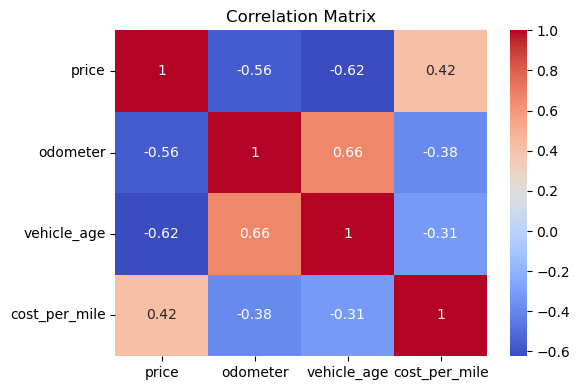

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = regional_df[["price", "odometer", "vehicle_age", "cost_per_mile"]].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 16. Which states have the most consistent pricing (low variance)?

In [21]:
price_var = (
    regional_df.groupby("state")["price"]
    .std()
    .reset_index(name="price_std")
    .sort_values("price_std")
)

print("Most Consistent Pricing (Low Std Dev):")
display(price_var.head())

print("Most Volatile Pricing (High Std Dev):")
display(price_var.tail())

Most Consistent Pricing (Low Std Dev):


,state,price_std
28,nd,9638.435663
7,dc,11058.580443
30,nh,11261.085216
25,ms,11599.420092
39,ri,11789.240254


Most Volatile Pricing (High Std Dev):


,state,price_std
8,de,16301.740729
37,or,17516.086578
13,id,17976.991933
44,ut,18559.065137
47,wa,20022.919276


## 17. Are there regional clusters with similar pricing behavior?

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = state_summary[["median_price", "median_odometer", "median_vehicle_age", "median_cpm"]]

scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=1)
state_summary["score"] = pca.fit_transform(scaled)

# Split into 2 clusters based on median score
threshold = state_summary["score"].median()
state_summary["cluster"] = (state_summary["score"] > threshold).astype(int)

state_summary[["state", "cluster"]].sort_values("cluster")

,state,cluster
25,ms,0
23,mn,0
22,mi,0
21,me,0
39,ri,0
19,ma,0
27,nc,0
41,sd,0
31,nj,0
28,nd,0


In [6]:
state_summary.groupby("cluster")[["median_price", "median_odometer", "median_vehicle_age", "median_cpm"]].mean()

,median_price,median_odometer,median_vehicle_age,median_cpm
cluster,,,,
0,15297.538462,101087.076923,8.423077,0.156339
1,20773.160000,80908.640000,6.800000,0.266350


### Cluster Analysis

#### Cluster 0 = “Value States”
- Buyers get more miles per dollar
- Cars are older but cheaper
- Inventory is more worn but affordable
- Dealers compete on price

#### Cluster 1 = “Premium States”
- Buyers pay more for newer, lower‑mileage cars
- Higher cost‑per‑mile means worse value
- Dealers can command higher prices
- Inventory is newer and more desirable

In [4]:
import pandas as pd

state_summary["price_cluster"] = pd.qcut(
    state_summary["median_price"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

display(state_summary[["state", "median_price", "price_cluster"]])

,state,median_price,price_cluster
0,ak,22999.0,High
1,al,21990.0,High
2,ar,20000.0,High
3,az,17998.0,Mid-High
4,ca,15995.0,Mid-Low
5,co,17990.0,Mid-Low
6,ct,11985.0,Low
7,dc,13450.0,Low
8,de,12000.0,Low
9,fl,16995.0,Mid-Low
